# 06b — Deep Learning: LSTM Forecaster (Tabular)
**Objetivo:** Predecir consumo energético 24 horas adelante usando LSTM con input tabular.  
**Diferencia vs MLP:** El LSTM procesa cada fila como una secuencia de longitud 1 `(batch, seq_len=1, features)`.  
**Comparación:** LSTM-Tabular vs MLP vs modelos previos.

## 0. Imports y configuración

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
import sys

sys.path.append('../src')

from modeling.DL_LSTM_tab import (
    set_seed,
    build_model,
    get_dataloaders,
    train_model,
    evaluate_model,
    save_model,
    load_model,
    DEVICE
)
from utils.metrics import calculate_metrics, print_metrics

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")

fh         = 24
TARGET_COL = 'PJME_MW'

Path('../reports/figures').mkdir(parents=True, exist_ok=True)

PyTorch version : 2.10.0+cpu
Device          : cpu


## 1. Cargar datos

In [2]:
data_dir = Path('../data/processed')

train_df = pd.read_csv(data_dir / f'train_{fh}hr.csv', index_col='Datetime', parse_dates=True)
val_df   = pd.read_csv(data_dir / f'val_{fh}hr.csv',   index_col='Datetime', parse_dates=True)
test_df  = pd.read_csv(data_dir / f'test_{fh}hr.csv',  index_col='Datetime', parse_dates=True)

train_df = train_df.asfreq('h')
val_df   = val_df.asfreq('h')
test_df  = test_df.asfreq('h')

print(f"Train : {train_df.shape}  {train_df.index[0].date()} → {train_df.index[-1].date()}")
print(f"Val   : {val_df.shape}    {val_df.index[0].date()} → {val_df.index[-1].date()}")
print(f"Test  : {test_df.shape}   {test_df.index[0].date()} → {test_df.index[-1].date()}")

Train : (101622, 50)  2002-01-09 → 2013-08-13
Val   : (21752, 50)    2013-08-14 → 2016-02-06
Test  : (21753, 50)   2016-02-07 → 2018-08-02


## 2. DataLoaders + Scaler

In [3]:
train_loader, val_loader, test_loader, scaler_y, feature_cols = get_dataloaders(
    train_df, val_df, test_df,
    target_col = TARGET_COL,
    batch_size = 64,
)

# Verificar shape — debe ser (batch, seq_len=1, n_features)
sample_X, sample_y = next(iter(train_loader))
print(f"\nX shape : {sample_X.shape}  → (batch, seq_len, features)")
print(f"y shape : {sample_y.shape}  → (batch, 1)")

Input size (n_features) : 49
X shape en dataset      : (batch, seq_len=1, 49)
Train batches: 1588 | Val: 340 | Test: 340

X shape : torch.Size([64, 1, 49])  → (batch, seq_len, features)
y shape : torch.Size([64, 1])  → (batch, 1)


## 3. Construir modelo

In [4]:
set_seed(22)

model = build_model(
    train_loader,
    hidden_size = 64,
    num_layers  = 2,
    dropout     = 0.2,
)

Semilla fijada: 22
Arquitectura : LSTM(49 → hidden=64, layers=2) → 1
Parámetros   : 62,785
Device       : cpu


## 4. Entrenamiento

In [5]:
history = train_model(
    model,
    train_loader,
    val_loader,
    epochs    = 50,
    lr        = 1e-3,
    patience  = 10,
    save_path = '../models/dl_best_lstm_tabular.pt',
)

Epoch   1/50 | Train: 0.1886 | Val: 0.1692 | Best: 0.1692 | LR: 1.00e-03
Epoch  10/50 | Train: 0.1195 | Val: 0.1609 | Best: 0.1530 | LR: 1.00e-03

Early stopping en época 15 (sin mejora por 10 épocas)

Mejor Val Loss: 0.1530 → guardado en ../models/dl_best_lstm_tabular.pt


In [6]:
# Cargar modelo guardado — comentar bloque build_model si se usa esto
# model, scaler_y, feature_cols, history = load_model(path='../models/dl_lstm_tabular.pt')

### Curva de entrenamiento

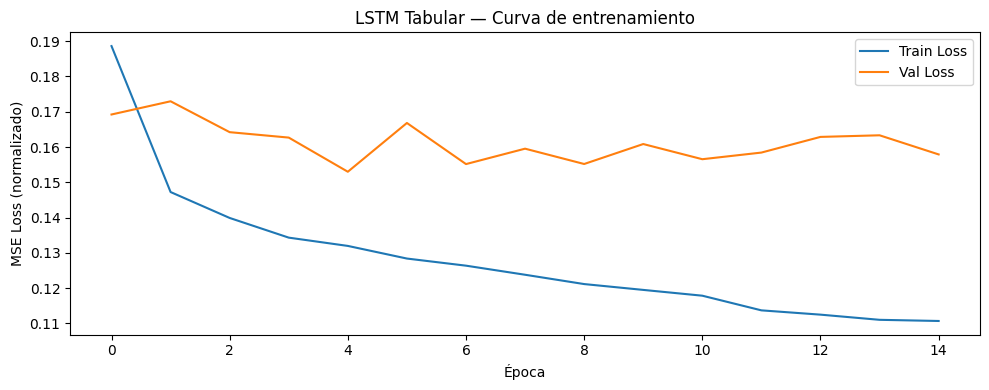

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train_loss'], label='Train Loss')
ax.plot(history['val_loss'],   label='Val Loss')
ax.set_xlabel('Época')
ax.set_ylabel('MSE Loss (normalizado)')
ax.set_title('LSTM Tabular — Curva de entrenamiento')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/dl_lstm_tabular_training_curve.png', dpi=150)
plt.show()

## 5. Evaluación

In [8]:
model.load_state_dict(torch.load('../models/dl_best_lstm_tabular.pt', map_location=DEVICE))

metrics_val,  y_true_val,  y_pred_val  = evaluate_model(model, val_loader,  scaler_y, set_name='Val')
metrics_test, y_true_test, y_pred_test = evaluate_model(model, test_loader, scaler_y, set_name='Test')


Métricas - Val
Mean_True:  31,496.88 MW
Std_True: 6,184.08 MW
MAE:  1,853.91 MW
RMSE: 2,543.47 MW
MAPE: 5.71%
R²:   0.8308


Métricas - Test
Mean_True:  31,101.32 MW
Std_True: 6,446.02 MW
MAE:  2,034.94 MW
RMSE: 2,764.79 MW
MAPE: 6.36%
R²:   0.8160



### Predicciones vs Real

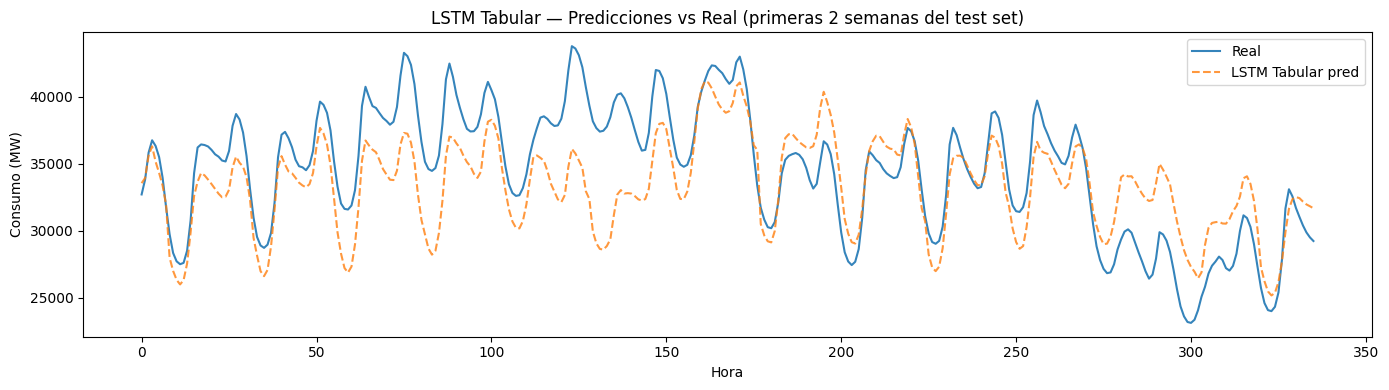

In [9]:
N = 24 * 14  # 2 semanas

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_true_test[:N], label='Real',              alpha=0.9)
ax.plot(y_pred_test[:N], label='LSTM Tabular pred', alpha=0.8, linestyle='--')
ax.set_xlabel('Hora')
ax.set_ylabel('Consumo (MW)')
ax.set_title('LSTM Tabular — Predicciones vs Real (primeras 2 semanas del test set)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/dl_lstm_tabular_predictions.png', dpi=150)
plt.show()

## 6. Guardar modelo y resultados

In [ ]:
save_model(model, scaler_y, feature_cols, history=history, path='../models/dl_lstm_tabular.pt')

metrics_test['model'] = 'LSTM_Tabular'
results_df = pd.DataFrame([metrics_test])
results_df.to_csv('../reports/metrics/dl_lstm_tabular_metrics.csv', index=False)
print(results_df.T)

Modelo guardado en ../models/dl_lstm_tabular.pt
                      0
Mean_True  31101.322266
Std_True    6446.024902
MAE         2034.937744
RMSE        2764.788509
MAPE           6.362294
R2             0.816033
set                Test
model      LSTM_Tabular
